# Optical absorption in twisted bilayer graphene (Koshino et al.)

This notebook presents a clean implementation based on the paper:

**M. Koshino and E. McCann**  
*Optical absorption in twisted bilayer graphene* (2013)  
https://journals.aps.org/prb/abstract/10.1103/PhysRevB.87.205404

**Original code author**  
Sarbajit Mazumdar  
Doctoral Researcher, Julius-Maximilians-Universitat Wurzburg  
Email: sarbajit.mazumdar@uni-wuerzburg.de

## Scope
- Build periodic commensurate TBG lattice.
- Use Moon-Koshino-inspired Slater-Koster hopping.
- Compute and plot bands along $K \to \Gamma \to M \to K^{\prime}$.
- Compute DOS from a 2D sampling of the irreducible Brillouin-zone triangle.
- Plot a combined band-structure and DOS figure.


## Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvalsh
from tqdm import tqdm, trange
from moirepy import BilayerMoireLattice, HexagonalLayer

## Build commensurate TBG lattice

For `theta ~ 3.89 deg`, use `(m,n)=(8,9)`. In this MoirePy setup:
- lower layer: `ll=(8,9)`
- upper layer: `ul=(9,8)`

In [12]:
lattice = BilayerMoireLattice(
    latticetype=HexagonalLayer,
    ll1=8, ll2=9,
    ul1=9, ul2=8,
    n1=1, n2=1,
    pbc=True,
    verbose=True,
)

twist angle = 0.0679 rad (3.8902 deg)
434 cells in upper lattice
434 cells in lower lattice


## Tight-binding parameters (Moon-Koshino)

Paper values used:

$$
a = 0.246\,\mathrm{nm}, \qquad
a_0 = \frac{a}{\sqrt{3}} \approx 1.42 \times 10^{-1}\,\mathrm{nm}
$$

$$
d_0 = 0.335\,\mathrm{nm}, \qquad
\delta_0 = 0.184\,a
$$

$$
V_{pp\pi}^{0} = -2.7\,\mathrm{eV}, \qquad
V_{pp\sigma}^{0} = 4.8 \times 10^{-1}\,\mathrm{eV}
$$

We apply the same style cutoff:

$$
d > 4a_0 \;\Rightarrow\; t(d) \approx 0
$$


In [13]:
a_graphene = 1.0
a0 = a_graphene / np.sqrt(3.0)
d0 = 0.335 / 0.246
delta0 = 0.184

VPP_PI0 = -2.7
VPP_SIGMA0 = 0.48

r3d_cut = 4.0 * a0
inter_layer_radius = 2.5

# Build bond/connection lists once.
lattice.generate_connections(inter_layer_radius=inter_layer_radius)

## Hopping functions

- `intralayer_hopping`: nearest-neighbor graphene hopping.
- `interlayer_hopping`: Slater-Koster-style distance-dependent hopping.

In [14]:
def intralayer_hopping(pos_i, pos_j, R, type_i, type_j, lattice, **kwargs):
    """
    MoirePy's built-in hexagonal layer generates nearest-neighbor intralayer bonds.
    Use dominant nearest-neighbor graphene hopping.
    """
    rij = pos_i - (pos_j + R)
    dist = np.linalg.norm(rij, axis=1)

    vals = np.zeros_like(dist, dtype=np.float64)
    nn_mask = np.isclose(dist, a0, atol=1e-6, rtol=1e-5)

    vals[nn_mask] = VPP_PI0
    return vals


def interlayer_hopping(pos_i, pos_j, R, type_i, type_j, lattice, **kwargs):
    """
    Moon-Koshino-inspired Slater-Koster interlayer hopping.
    """
    lateral = pos_i - (pos_j + R)
    rho = np.linalg.norm(lateral, axis=1)
    d = np.sqrt(rho**2 + d0**2)

    vals = np.zeros_like(d, dtype=np.float64)
    mask = d <= r3d_cut
    if not np.any(mask):
        return vals

    dm = d[mask]
    cos2 = (d0 / dm) ** 2

    Vpp_pi = VPP_PI0 * np.exp(-(dm - a0) / delta0)
    Vpp_sigma = VPP_SIGMA0 * np.exp(-(dm - d0) / delta0)

    vals[mask] = Vpp_pi * (1.0 - cos2) + Vpp_sigma * cos2
    return vals

## Real-space Hamiltonian

In [15]:
H_real = lattice.generate_hamiltonian(
    tll=intralayer_hopping,
    tuu=intralayer_hopping,
    tul=interlayer_hopping,
    tlu=interlayer_hopping,
    tlself=0.0,
    tuself=0.0,
    data_type=np.complex128,
)

print("Hamiltonian dimension =", H_real.shape)

Hamiltonian dimension = (868, 868)


## High-symmetry path in moire Brillouin zone

Path used: $K \to \Gamma \to M \to K^{\prime}$.

In [ ]:
def reciprocal_vectors(a1, a2):
    area = a1[0] * a2[1] - a1[1] * a2[0]
    b1 = 2.0 * np.pi * np.array([a2[1], -a2[0]]) / area
    b2 = 2.0 * np.pi * np.array([-a1[1], a1[0]]) / area
    return b1, b2

L1 = lattice.mlv1
L2 = lattice.mlv2

G1, G2 = reciprocal_vectors(L1, L2)

Gamma = np.array([0.0, 0.0])
K = (2.0 * G1 + G2) / 3.0
M = (G1 + G2) / 2.0
Kp = (G1 + 2.0 * G2) / 3.0


def interpolate_path(points, n_per_segment=40):
    xs = [0.0]
    klist = [np.array(points[0], dtype=float)]
    ticks = [0.0]

    for p0, p1 in zip(points[:-1], points[1:]):
        p0 = np.array(p0, dtype=float)
        p1 = np.array(p1, dtype=float)

        for j in range(1, n_per_segment + 1):
            t = j / n_per_segment
            k = (1.0 - t) * p0 + t * p1
            xs.append(xs[-1] + np.linalg.norm(k - klist[-1]))
            klist.append(k)

        ticks.append(xs[-1])

    return np.array(klist), np.array(xs), np.array(ticks)

k_path, x_axis, tick_pos = interpolate_path([K, Gamma, M, Kp], n_per_segment=40)
tick_labels = ["K", r"$\Gamma$", "M", "K'"]

print("Number of k-points:", len(k_path))

Number of k-points: 61


## Compute band structure along the high-symmetry path

This cell evaluates eigenvalues of $H(k)$ along $K \to \Gamma \to M \to K^{\prime}$.


In [17]:
bands = []

for kvec in tqdm(k_path, desc="Calculating bands"):
    phase = lattice.get_phase(kvec)
    Hk = H_real.multiply(phase)
    vals = eigvalsh(Hk.todense())
    bands.append(vals)

bands = np.array(bands)

Calculating bands: 100%|██████████| 61/61 [00:08<00:00,  7.44it/s]


## Compute DOS on the irreducible Brillouin-zone triangle

This cell samples the triangle and builds a smoothed DOS in the target energy window.


In [18]:
from scipy.ndimage import gaussian_filter1d

Gamma = np.array([0.0, 0.0])
M_pt = 0.5 * G1
K_pt = (2.0 / 3.0) * G1 + (1.0 / 3.0) * G2

N_side = 60
all_energies = []

for i in tqdm(range(N_side), desc="Calculating DOS"):
    for j in range(i + 1):
        u = i / (N_side - 1)
        v = j / (N_side - 1)
        kvec = (1.0 - u) * Gamma + (u - v) * M_pt + v * K_pt

        phase = lattice.get_phase(kvec)
        Hk = H_real.multiply(phase)
        vals = eigvalsh(Hk.todense())

        mask = (vals >= -0.7) & (vals <= 0.7)
        all_energies.extend(vals[mask])

all_energies = np.array(all_energies)

e_min, e_max = -0.6, 0.6
energy_grid = np.linspace(e_min, e_max, 500)
dos_raw, _ = np.histogram(all_energies, bins=energy_grid)
bin_centers = (energy_grid[:-1] + energy_grid[1:]) / 2.0
dos_smooth = gaussian_filter1d(dos_raw, sigma=1.25)


Calculating DOS: 100%|██████████| 60/60 [05:52<00:00,  5.88s/it]


## Plot band structure and DOS

The final figure shows the band structure (left) and DOS (right) using the same energy axis.


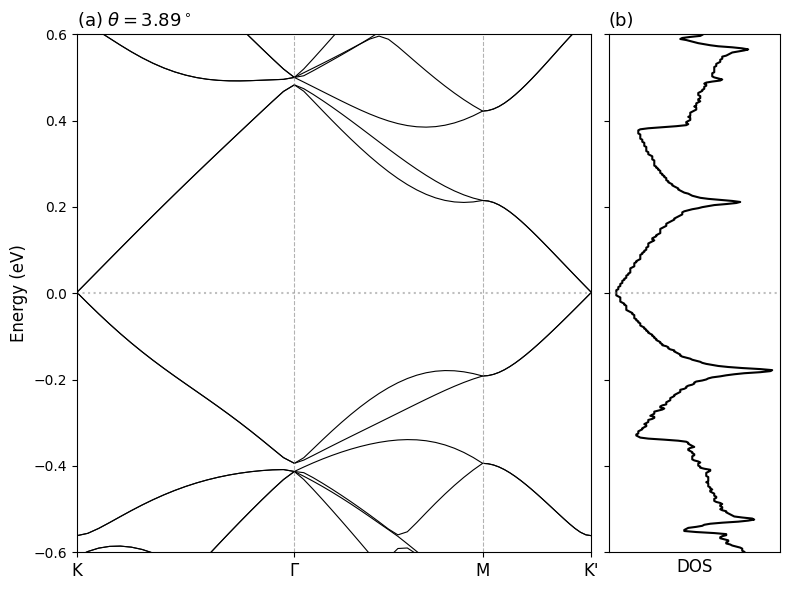

In [19]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(8, 6),
    sharey=True,
    gridspec_kw={"width_ratios": [3, 1]},
)

ax1.plot(x_axis, bands, "k", lw=0.8)
for xc in tick_pos[1:-1]:
    ax1.axvline(xc, color="gray", ls="--", lw=0.8, alpha=0.6)
ax1.set_xticks(tick_pos)
ax1.set_xticklabels(tick_labels, fontsize=12)
ax1.set_ylabel("Energy (eV)", fontsize=12)
ax1.set_title(r"(a) $\theta = 3.89^\circ$", loc="left", fontsize=13)
ax1.set_xlim(x_axis[0], x_axis[-1])

ax2.plot(dos_smooth, bin_centers, color="black")
ax2.set_xlabel("DOS", fontsize=12)
ax2.set_title("(b)", loc="left", fontsize=13)
ax2.set_xticks([])

for ax in (ax1, ax2):
    ax.axhline(0.0, color="gray", linestyle=":", alpha=0.5)
    ax.set_ylim(e_min, e_max)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)